In [9]:
import stim
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# For a d (even) distance periodic surface code
# unit cube at location (i,j,k)

d = 2
i_max = d
j_max = d
#time direction
k_max = 1

no_cubes = int((i_max * j_max)/2 * k_max)
bottom_boundary = no_cubes * 3
qubits =  int(12 * (i_max * j_max)/2 * k_max + bottom_boundary)
print("Number of qubits: ", qubits)

Number of qubits:  30


In [11]:
circuit = stim.Circuit()
circuit.append_operation("R", list(range(qubits)))
circuit.append_operation("H", list(range(qubits)))

#doing CZ to make 6 rings
for k in range(k_max):
    for i in range(i_max):
        for j in range(j_max):
            if (i+j)%2 == 0:
                #non boundary qubits
                print("i: ", i, " j: ", j, " k: ", k)
                #qubit_index
                q_i = int(bottom_boundary + (12*k*j_max*i_max/2) + (12 * ((i * j_max/2) + (j//2))))
                print("q_i: ", q_i)
                circuit.append_operation("CZ", [q_i, q_i + 1])
                circuit.append_operation("CZ", [q_i + 1, q_i + 2])
                circuit.append_operation("CZ", [q_i + 2, q_i + 5])
                circuit.append_operation("CZ", [q_i , q_i + 3])
                circuit.append_operation("CZ", [q_i + 3, q_i + 4])
                circuit.append_operation("CZ", [q_i + 4, q_i + 5])

                circuit.append_operation("CZ", [q_i + 6, q_i + 7])
                circuit.append_operation("CZ", [q_i + 7, q_i + 8])
                circuit.append_operation("CZ", [q_i + 8, q_i + 11])
                circuit.append_operation("CZ", [q_i + 6, q_i + 9])
                circuit.append_operation("CZ", [q_i + 9, q_i + 10])
                circuit.append_operation("CZ", [q_i + 10, q_i + 11])

                #boundary qubits
                if k == 0:
                    q_i = int((3 * ((i * j_max/2) + (j//2))))
                    print("boundary q_i: ", q_i)
                    circuit.append_operation("CZ", [q_i , q_i + 1])
                    circuit.append_operation("CZ", [q_i + 1, q_i + 2])

i:  0  j:  0  k:  0
q_i:  6
boundary q_i:  0
i:  1  j:  1  k:  0
q_i:  18
boundary q_i:  3


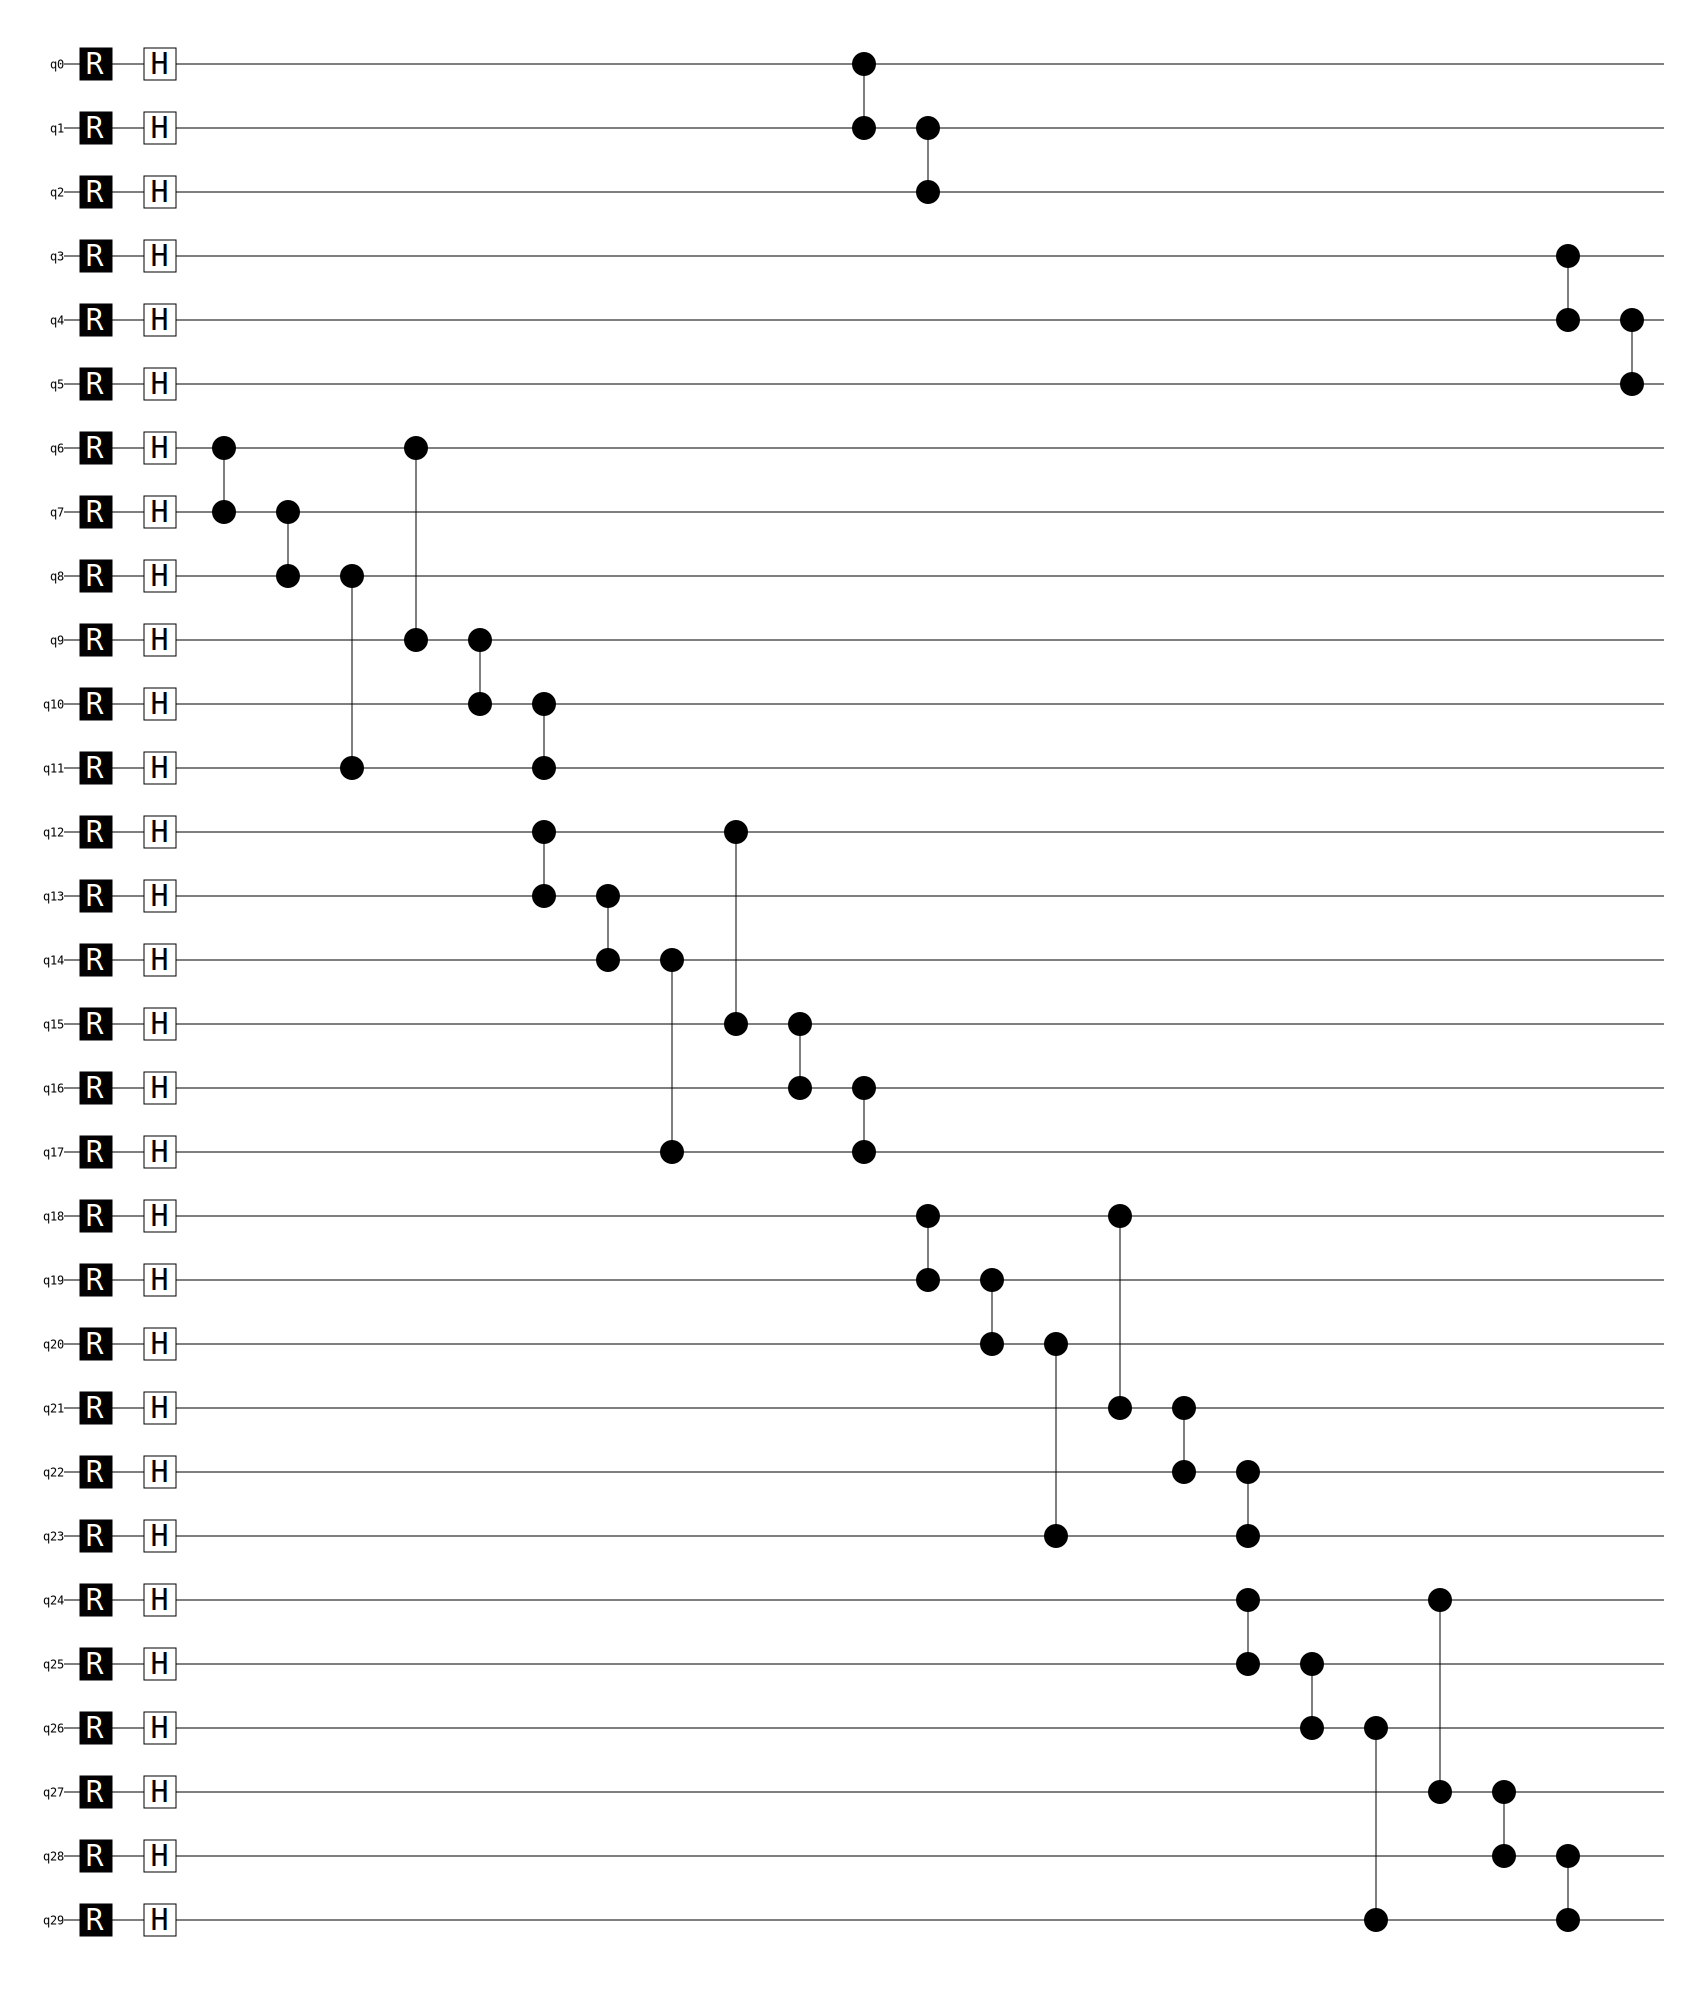

In [12]:
circuit.diagram('timeline-svg')

In [13]:
def fusion_ideal(circuit_in, q_1, q_2):
    """
    Performs ideal circuit of a non-probabilistic fusion in a circuit on
    qubits specified. No error. Note if q_1 and q_2 arent existing qubits, stim will create them and measure.

    Parameters
    ----------
    circuit_in : stim.Circuit
        The circuit to modify.
    q_1 : int
        The first qubit index.
    q_2 : int
        The second qubit index.

    Returns
    -------
    None
        The function modifies the input circuit in place.
        q_1 and q_2 are reset to 0.
    """
    circuit_in.append_operation("CNOT", [q_1, q_2])
    circuit_in.append_operation("H", [q_1])
    circuit_in.append_operation("M", [q_1, q_2])
    circuit_in.append_operation("R", [q_1, q_2])
    return 

In [14]:
fusion_ideal(circuit, 0, 1)

In [15]:
def qubit_index(i, j, k, q_no, i_max=i_max, j_max=j_max):
    """
    Returns the qubit index for a given (i,j,k) location in the surface code.

    Parameters
    ----------
    i : int
        The i coordinate (row).
    j : int
        The j coordinate (column).
    k : int
        The k coordinate (time).
    q_no : int
        The qubit number within the unit cube.
    i_max : int
        The maximum value of i (distance).
    j_max : int
        The maximum value of j (distance).

    Returns
    -------
    int
        The qubit index in the circuit.
    """
    bottom_boundary = int((i_max * j_max)/2 * 3)
    return int(bottom_boundary + (12*k*j_max*i_max/2) + (12 * ((i * j_max/2) + (j//2))) + q_no)

In [18]:
qubit_index(0, 0, 0, 0)
i_max 

2

In [ ]:
#adding fusion measurements

#should go through all unit blocks:
for i in range(i_max):
    for j in range(j_max):
        if (i+j)%2 == 0:
            #non boundary qubits
            print("i: ", i, " j: ", j)
            #qubit_index
            q_i = int(bottom_boundary + (12 * ((i * j_max/2) + (j//2))))
            print("q_i: ", q_i)
            fusion_ideal(circuit, q_i, q_i + 1)
            fusion_ideal(circuit, q_i + 1, q_i + 2)
            fusion_ideal(circuit, q_i + 2, q_i + 5)
            fusion_ideal(circuit, q_i + 3, q_i + 4)
            fusion_ideal(circuit, q_i + 3, q_i + 4)
            fusion_ideal(circuit, q_i + 4, q_i + 5)